In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [3]:
df = pd.read_csv("mnist_train.csv")

print("="*60)
print("First Five Records")
print("="*60)
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


First Five Records
   label  1x1  1x2  1x3  1x4  1x5  ...  28x23  28x24  28x25  28x26  28x27  28x28
0      5    0    0    0    0    0  ...      0      0      0      0      0      0
1      0    0    0    0    0    0  ...      0      0      0      0      0      0
2      4    0    0    0    0    0  ...      0      0      0      0      0      0
3      1    0    0    0    0    0  ...      0      0      0      0      0      0
4      9    0    0    0    0    0  ...      0      0      0      0      0      0

[5 rows x 785 columns]

Dataset Shape:
(60000, 785)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB
None

Summary Statistics:
              label      1x1      1x2  ...    28x26    28x27    28x28
count  60000.000000  60000.0  60000.0  ...  60000.0  60000.0  60000.0
mean       4.453933      0.0      0.0  ...      0.0      0.0      0.0
std        2.889270      0.0 


Input Feature Shape: (60000, 784)
Target Shape: (60000,)


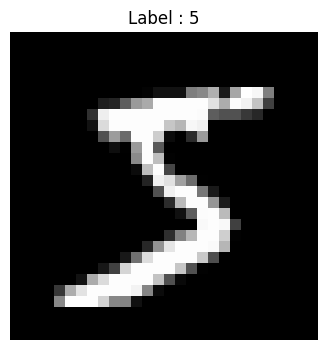

In [5]:
X = df.drop("label", axis=1)

# Target Variable
y = df["label"]

print("\nInput Feature Shape:", X.shape)
print("Target Shape:", y.shape)

plt.figure(figsize=(4,4))
plt.imshow(X.iloc[0].values.reshape(28,28), cmap='gray')
plt.title(f"Label : {y.iloc[0]}")
plt.axis("off")
plt.show()

In [8]:
print("\nMissing Values")
print(df.isnull().sum())

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.20,
                  random_state=42
                  )



Missing Values
label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64


In [9]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (48000, 784)
Testing Shape : (12000, 784)


In [15]:
model = Sequential()
model.add(Dense(128,
                activation='relu',
                                input_shape=(784,)))
model.add(Dense(64,
                activation='relu'))

model.add(Dense(10,
                activation='softmax'))
model.compile(
      optimizer='adam',
          loss='categorical_crossentropy',
              metrics=['accuracy']
              )
print("\nModel Summary")
model.summary()



Model Summary


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:

history = model.fit(
    X_train,
        y_train,
            validation_split=0.2,
                epochs=10,
                    batch_size=32,
                        verbose=1
                        )

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6631 - loss: 1.0639 - val_accuracy: 0.8190 - val_loss: 0.5866
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8631 - loss: 0.4732 - val_accuracy: 0.8846 - val_loss: 0.4033
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8927 - loss: 0.3719 - val_accuracy: 0.9006 - val_loss: 0.3459
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9046 - loss: 0.3298 - val_accuracy: 0.9091 - val_loss: 0.3155
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9130 - loss: 0.3018 - val_accuracy: 0.9148 - val_loss: 0.2947
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9188 - loss: 0.2800 - val_accuracy: 0.9207 - val_loss: 0.2730
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9246 - loss: 0.2590 - val_accuracy: 0.9247 - val_loss: 0.2580
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9288 - loss: 0.2417 - 

In [17]:
prediction = model.predict(X_test)

predicted_labels = np.argmax(prediction, axis=1)

actual_labels = np.argmax(y_test, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [18]:
loss, accuracy = model.evaluate(
      X_test,
          y_test,
              verbose=0
              )
print("\n")
print("="*60)
print("Test Accuracy")
print("="*60)

print("Accuracy :", round(accuracy*100,2),"%")



Test Accuracy
Accuracy : 93.91 %


In [19]:
cm = confusion_matrix(actual_labels, predicted_labels)

print("\nConfusion Matrix\n")
print(cm)



Confusion Matrix

[[1139    0    4    1    4    6    9    0   10    2]
 [   0 1283   11    3    1    2    1    2   16    3]
 [   5   10 1106    6    3    5   15    8   15    1]
 [   4    4   44 1092    1   26    5   12   23    8]
 [   2    2    4    1 1119    1   14    2    0   31]
 [  18    4   12   30    9  986   13    4   23    5]
 [   6    2    7    0    5    6 1145    0    6    0]
 [   5   10   21    4    9    0    0 1237    4    9]
 [   8   15   13   20    7   12   15    4 1061    5]
 [   7    4    4    7   32    7    0   21   11 1101]]


In [20]:
print("\nClassification Report\n")

print(classification_report(
    actual_labels,
        predicted_labels
        ))


Classification Report

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1175
           1       0.96      0.97      0.97      1322
           2       0.90      0.94      0.92      1174
           3       0.94      0.90      0.92      1219
           4       0.94      0.95      0.95      1176
           5       0.94      0.89      0.92      1104
           6       0.94      0.97      0.96      1177
           7       0.96      0.95      0.96      1299
           8       0.91      0.91      0.91      1160
           9       0.95      0.92      0.93      1194

    accuracy                           0.94     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.94      0.94      0.94     12000



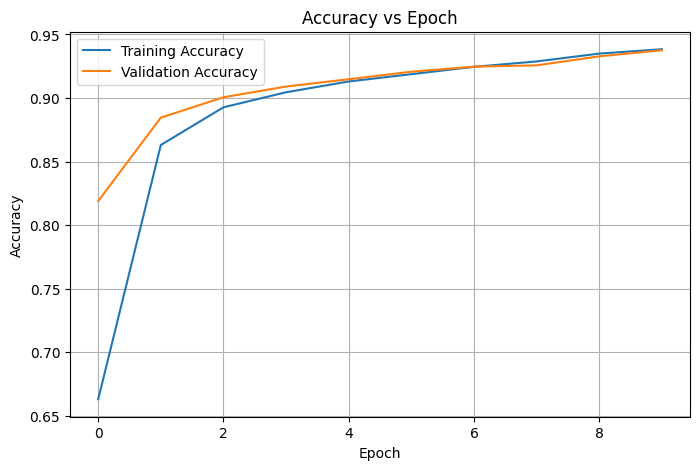

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

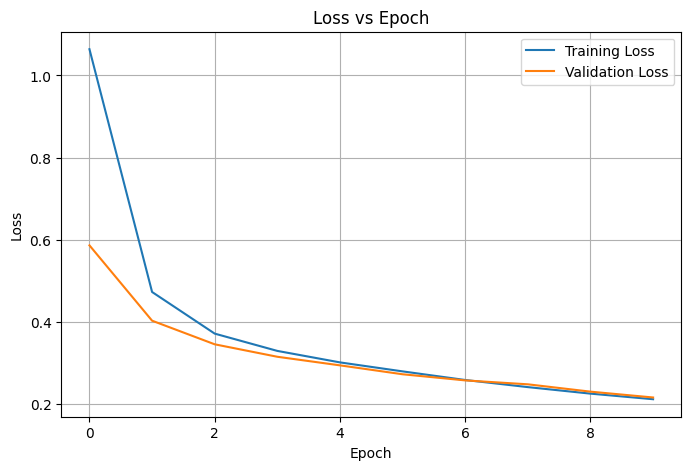

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

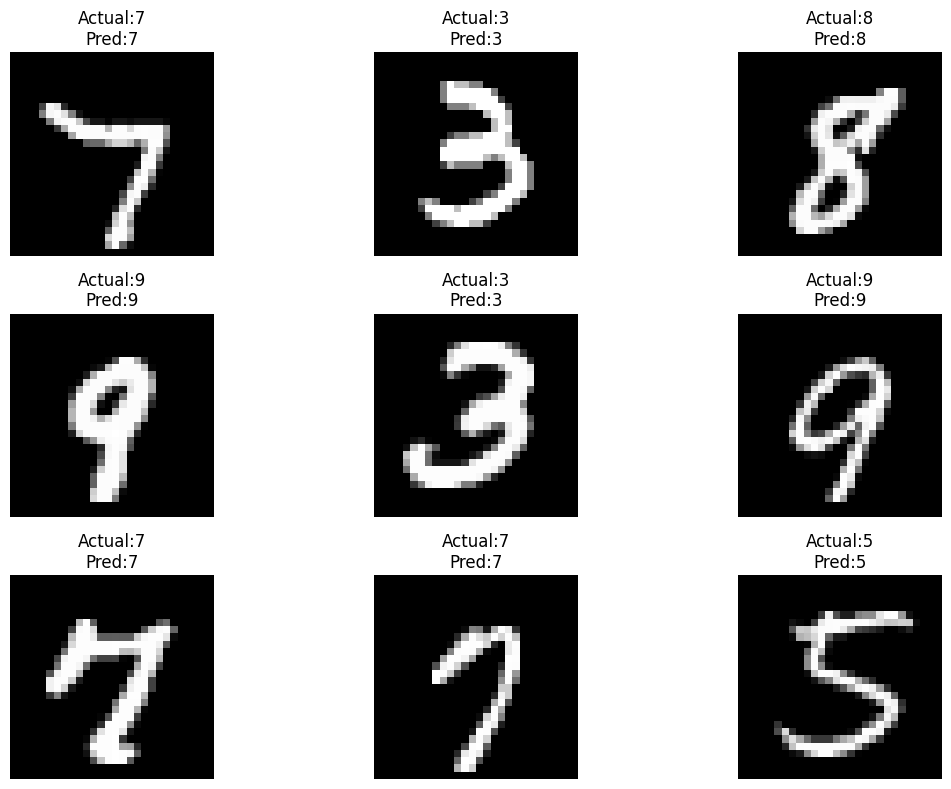

In [23]:
plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test.iloc[i].values.reshape(28,28),
                       cmap="gray")

    plt.title(
             f"Actual:{actual_labels[i]}\nPred:{predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()